# Plots night trajectories: 

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.dates import DateFormatter
import os
from scipy.stats import lognorm
import matplotlib.colors as colors

plt.rcParams["font.family"] = 'monospace'

from aerosol_functions import *


In [2]:
years = [2022, 2023, 2024]

possible_cols = ['DateTime', 'Traj_num', 'meteorological_grid_num', 'FORECAST_hour',
       'time_step', 'latitude', 'longitude', 'altitude', 'PRESSURE', 'THETA',
       'AIR_TEMP', 'RAINFALL', 'MIXDEPTH', 'RELHUMID', 'SPCHUMID', 'H2OMIXRA',
       'TERR_MSL', 'SUN_FLUX', 'arrival_time', 'latitude_previous',
       'longitude_previous', 'altitude_previous', 'distance', 'grid_lon',
       'grid_lat', 'obs']

hysplt_path = r'D:\HYSPLIT_dfs_nucleation\processed_years\nucleation'
dict_dtype = dict(zip(['Traj_num', 'grid_lon', 'grid_lat', 'time_step'], 
                          [np.int8, np.int16, np.int8, np.float16, np.float16]))

usecols=['DateTime', 'Traj_num','time_step', 'grid_lat', 'grid_lon', 'arrival_time',
         'MIXDEPTH', 'altitude', 'latitude', 'longitude', 'SUN_FLUX', 'RAINFALL'] 

DFs = []
if len(years) > 1: 
    for year in years:
        print(year)
        df_hysplit = pd.read_csv(r'D:\HYSPLIT_dfs_nucleation\processed_years\nucleation\dfs'+'\\'+str(year)+'.dat', 
                                 parse_dates=True, usecols=usecols, dtype=dict_dtype)
        DFs.append(df_hysplit)    
df_hysplit = pd.concat(DFs)
df_hysplit = df_hysplit.set_index('arrival_time')
df_hysplit.index = pd.to_datetime(df_hysplit.index)
print(df_hysplit.index[0])
print(df_hysplit.index[-1])
#df_hysplit_ml = df_hysplit[df_hysplit['altitude'] < df_hysplit['MIXDEPTH']].copy()
#del df_hysplit

2022
2023
2024
2022-04-17 12:00:00
2024-10-01 18:00:00


In [3]:
df_hysplit['time_step'].min()

-120.0

# Polar night altitude: 

df_hysplit

In [4]:
def read_in_growth_excel(path = r'C:\Users\DominicHeslinRees\NAIS_work\Classification',
                        filename='events_start_and_end_times_checked.xlsx'):
    df_NPF_plusgrowth = pd.read_excel(path+'\\'+filename, index_col=0, parse_dates=True)
    df_NPF_plusgrowth.index.name = 'event'
    df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_event'].dt.date
    df_NPF_plusgrowth['start_date'] = df_NPF_plusgrowth['start_date'].astype(str)
    df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_event'].dt.date
    df_NPF_plusgrowth['end_date'] = df_NPF_plusgrowth['end_date'].astype(str)
    return df_NPF_plusgrowth

def flatten(xss):
    return [x for xs in xss for x in xs]

def get_times_removed_duplicates(df_NPF_plusgrowth):
    timespans = []
    for i in range(len(df_NPF_plusgrowth)):
        try:
            start = df_NPF_plusgrowth['start_event'].iloc[i]
            end = df_NPF_plusgrowth['end_event'].iloc[i]
            timespan = pd.date_range(start,end,freq='15min')
            timespans.append(timespan)
        except:
            pass
    timespans = flatten(timespans)
    timespans = [str(x) for x in timespans]
    df_NPF_growth = pd.DataFrame(timespans, columns=['datetime'])
    df_NPF_growth['NPF_growth'] = 1
    df_NPF_growth = df_NPF_growth.set_index('datetime')
    df_NPF_growth = df_NPF_growth[~df_NPF_growth.index.duplicated(keep='first')]
    df_NPF_growth.index = pd.to_datetime(df_NPF_growth.index)
    return df_NPF_growth

In [5]:
df_NPF_plusgrowth = read_in_growth_excel()
df_NPF_growth = get_times_removed_duplicates(df_NPF_plusgrowth)
NPF_growth_datetime_list = df_NPF_growth.index
df_NPF_growth = df_NPF_growth.resample('H').mean()
df_NPF_growth = df_NPF_growth.dropna(how='all')
dates_list = df_NPF_growth.index
print(dates_list)

DatetimeIndex(['2022-04-17 12:00:00', '2022-04-17 13:00:00',
               '2022-04-17 14:00:00', '2022-04-17 15:00:00',
               '2022-04-17 16:00:00', '2022-04-17 17:00:00',
               '2022-04-17 18:00:00', '2022-04-17 19:00:00',
               '2022-04-17 20:00:00', '2022-04-17 21:00:00',
               ...
               '2024-10-01 20:00:00', '2024-10-01 21:00:00',
               '2024-10-01 22:00:00', '2024-10-01 23:00:00',
               '2024-10-02 00:00:00', '2024-10-02 01:00:00',
               '2024-10-02 02:00:00', '2024-10-02 03:00:00',
               '2024-10-02 04:00:00', '2024-10-02 05:00:00'],
              dtype='datetime64[ns]', name='datetime', length=3218, freq=None)


In [6]:
# 1. 2022-11-25 20:00 - 2022-11-26 15:00, 
# 2. 2023-10-25 20:00 - 2023-10-26 23:50, 
# 3ab. 2023-10-28 (x2, 01:00 12:00) – 2023-10-29 15:00, 
# 4. 2023-11-01 09:00 - 2023-11-02 18:00, 
# 5. 2023-11-02 21:00 -2023-11-03 06:00. 

polar_night_events = []
for start, end in zip(['2022-11-25 20:00','2023-10-25 20:00','2023-10-28 01:00', '2023-10-28 12:00', '2023-11-01 09:00','2023-11-02 21:00'],
                        ['2022-11-26 15:00', '2023-10-26 23:50', '2023-10-29 15:00', '2023-10-29 15:00','2023-11-02 18:00', '2023-11-03 06:00']):
    event_range = pd.date_range(start, end, freq='1H')
    event_range = [str(pd.to_datetime(x)) for x in event_range]
    polar_night_events.append(event_range)
    
polar_night_events = flatten(polar_night_events)
event_dates_notpolar = list(set(dates_list)-set(polar_night_events))

In [7]:
print(len(df_hysplit))
df_hysplit = df_hysplit.reset_index()

df_hysplit_ntevents = df_hysplit[~df_hysplit['arrival_time'].isin(dates_list)]
print(len(df_hysplit_ntevents))

df_hysplit_polarnight = df_hysplit[df_hysplit['arrival_time'].isin(polar_night_events)]
df_hysplit_events_not_polar = df_hysplit[df_hysplit['arrival_time'].isin(event_dates_notpolar)]
print(len(df_hysplit_events_not_polar))
print(len(df_hysplit_polarnight))

70454502
59941296
10513206
427977


In [8]:
def df_alt_to_dict(df_trajs):
    dfs_trajs = [x for _, x in df_trajs.groupby('arrival_time')]
    #average by timestep - groupby and then plot
    dict_arrival_time_traj = {}
    for df_trajs in dfs_trajs:
        arrival_time = df_trajs['arrival_time'].iloc[0]
        df_altitude = df_trajs.groupby('time_step').mean()['altitude'].to_frame()[::-1]
        df_altitude.index = df_altitude.index*(-1)
        dict_arrival_time_traj[arrival_time] = df_altitude
    return dict_arrival_time_traj

In [9]:
dict_arrival_time_traj = df_alt_to_dict(df_hysplit_ntevents)

C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_altitude = df_trajs.groupby('time_step').mean()['altitude'].to_frame()[::-1]
C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_altitude = df_trajs.groupby('time_step').mean()['altitude'].to_frame()[::-1]
C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will 

In [10]:
dict_arrival_time_traj_notpolarnight = df_alt_to_dict(df_hysplit_events_not_polar)
dict_arrival_time_traj_polarnight = df_alt_to_dict(df_hysplit_polarnight)

C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_altitude = df_trajs.groupby('time_step').mean()['altitude'].to_frame()[::-1]
C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_altitude = df_trajs.groupby('time_step').mean()['altitude'].to_frame()[::-1]
C:\Users\DominicHeslinRees\AppData\Local\Temp\ipykernel_28144\758641880.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will 

In [11]:
#October 26 to February 15
# 1. 2022-11-25 20:00 - 2022-11-26 15:00, 
# 2. 2023-10-25 20:00 - 2023-10-26 23:50, 
# 3ab. 2023-10-28 (x2, 01:00 12:00) – 2023-10-29 15:00, 
# 4. 2023-11-01 09:00 - 2023-11-02 18:00, 
# 5. 2023-11-02 21:00 -2023-11-03 06:00.  

# event_dates = ZEP_class[['Class Ia', 'Class Ib', 'Class II']].dropna(how='all').index
# event_dates = [str(x.date()) for x in event_dates]
# polar_night = ['2022-11-25', '2022-11-26', '2023-10-25', '2023-10-26', '2023-10-28', '2023-10-29', '2023-11-01', '2023-11-02', '2023-11-03']
# event_dates_notpolar = list(set(event_dates)-set(polar_night))

In [12]:
def flatten(xss):
    return [x for xs in xss for x in xs]

def append_to_list(dict_arrival_time_trajs, select_polarnight=False,
                event_dates_notpolar=None, polar_night=None):
    alts = []
    for arrival_time, df_alt in dict_arrival_time_trajs.items():
        arrival_time_date = pd.to_datetime(arrival_time).date()         
        c='k'; ms=1
        df_alt = df_alt[df_alt.index<45].copy()
        print(df_alt)
        if select_polarnight == False:
            if str(arrival_time_date) in event_dates_notpolar:
                x = df_alt.altitude.values
                alts.append(x)
        if select_polarnight == True:
            if str(arrival_time_date) in polar_night:
                x = df_alt.altitude.values
                alts.append(x)
    alts = flatten(alts)
    return alts

def append_to_list(dict_arrival_time_trajs, select_polarnight=False,
                event_dates_notpolar=None, polar_night=None):
    alts = []
    for arrival_time, df_alt in dict_arrival_time_trajs.items():
        #df_alt = df_alt[df_alt.index<45].copy() #timestep days
        print(df_alt)
        x = df_alt.altitude.values
        alts.append(x)
    alts = flatten(alts)
    return alts

In [13]:
alts = append_to_list(dict_arrival_time_traj)

             altitude
time_step            
-0.0       250.000000
 1.0       247.181481
 2.0       241.822222
 3.0       237.055556
 4.0       233.133333
...               ...
 116.0     647.325926
 117.0     652.948148
 118.0     660.888889
 119.0     668.937037
 120.0     677.937037

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0       252.407407
 2.0       252.955556
 3.0       252.103704
 4.0       246.081481
...               ...
 116.0     657.896296
 117.0     661.511111
 118.0     676.633333
 119.0     697.229630
 120.0     717.603704

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0       258.151852
 2.0       263.737037
 3.0       268.066667
 4.0       268.911111
...               ...
 116.0     535.251852
 117.0     543.218519
 118.0     550.837037
 119.0     557.755556
 120.0     557.270370

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0

In [14]:
alts_polarnight = append_to_list(dict_arrival_time_traj_polarnight)
alts_notpolarnight = append_to_list(dict_arrival_time_traj_notpolarnight)

             altitude
time_step            
-0.0       250.000000
 1.0       246.588889
 2.0       246.107407
 3.0       248.018519
 4.0       250.700000
...               ...
 116.0     368.314815
 117.0     361.644444
 118.0     359.588889
 119.0     367.137037
 120.0     381.133333

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0       243.807407
 2.0       240.429630
 3.0       240.451852
 4.0       242.888889
...               ...
 116.0     326.711111
 117.0     327.629630
 118.0     330.933333
 119.0     337.003704
 120.0     345.037037

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0       243.151852
 2.0       236.629630
 3.0       233.477778
 4.0       234.451852
...               ...
 116.0     477.011111
 117.0     458.062963
 118.0     427.118519
 119.0     390.925926
 120.0     374.162963

[121 rows x 1 columns]
             altitude
time_step            
-0.0       250.000000
 1.0

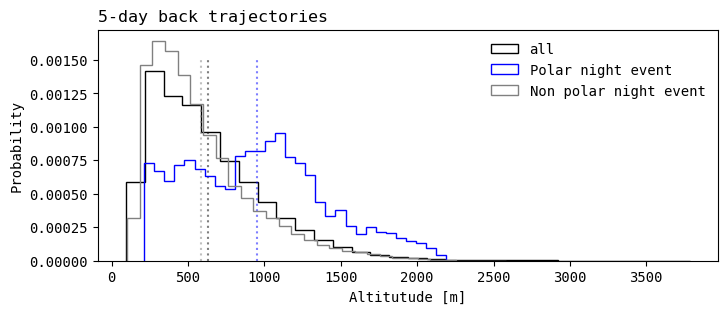

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
plt.hist(alts, density=True, bins=30, histtype='step', label='all', color='k')
mean_alt = np.mean(alts)
ax.vlines(mean_alt, ymin=0, ymax=0.0015, color='k', alpha=.5, ls=':')

plt.hist(alts_polarnight, density=True, bins=30, histtype='step', label='Polar night event', color='b')
mean_pn = np.mean(alts_polarnight)
ax.vlines(mean_pn, ymin=0, ymax=0.0015, color='b', alpha=.5, ls=':')

plt.hist(alts_notpolarnight, density=True, bins=30, histtype='step', label='Non polar night event', color='gray')
mean_notpn = np.mean(alts_notpolarnight)
ax.vlines(mean_notpn, ymin=0, ymax=0.0015, color='gray', alpha=.5, ls=':')

plt.legend(frameon=False)
plt.ylabel('Probability')
plt.xlabel('Altitutude [m]')
plt.title('5-day back trajectories', loc='left')
plt.show()